# Ola Ride Bookings Analysis: Trends, Patterns & Insights

# Introduction

**This notebook dives into Ola ride bookings data to explore key trends and patterns. We analyze ride volumes, peak hours, popular routes, and customer behavior to gain actionable insights into Ola’s operations and understand how demand varies across time and locations.**

# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
import warnings
from datetime import datetime
import calendar

warnings.filterwarnings('ignore')

plt.style.use('dark_background')

electric_palette = ["#66FCF1", "#C3073F", "#F9E076", "#ADFF2F", "#FF8C00", "#7B68EE", "#00FF7F"]
sns.set_palette(sns.color_palette(electric_palette))

plt.rcParams.update({
    'figure.figsize': (16, 9),
    'axes.facecolor': '#0B0C10',
    'figure.facecolor': '#0B0C10',
    'grid.color': '#1F2833',
    'grid.alpha': 0.4,
    'axes.edgecolor': '#45A29E',
    'axes.labelcolor': '#C5C6C7',
    'xtick.color': '#C5C6C7',
    'ytick.color': '#C5C6C7',
    'axes.titlecolor': '#66FCF1',
    'axes.titlesize': 18,
    'axes.titleweight': 'bold',
    'font.size': 12,
    'legend.facecolor': '#1F2833'
})

# Custom Plotly Theme
pio.templates["electric_midnight"] = go.layout.Template(
    layout=go.Layout(
        paper_bgcolor='#0B0C10',
        plot_bgcolor='#0B0C10',
        font=dict(color='#C5C6C7'),
        colorway=electric_palette
    )
)
pio.templates.default = "electric_midnight+plotly_dark"

# Loading The Data

In [2]:
import io
print("Loading data...")

df = pd.read_csv('/kaggle/input/datasets/shayanzk/ola-ride-bookings-dataset/rideBookings.csv')

print(f"Data loaded successfully!")
print(f"Shape of dataset: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

Loading data...
Data loaded successfully!
Shape of dataset: (150000, 21)

First 5 rows:


,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


# Checking columns names and data types

In [3]:
print("Dataset Info:")
print("-" * 50)
df.info()

Dataset Info:
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        1050

# Statistical Summary

In [4]:
print("Statistical Summary:")
print("-" * 50)
df.describe()

Statistical Summary:
--------------------------------------------------


,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Cancelled Rides by Driver,Incomplete Rides,Booking Value,Ride Distance,Driver Ratings,Customer Rating
count,139500.000000,102000.000000,10500.0,27000.0,9000.0,102000.000000,102000.000000,93000.000000,93000.000000
mean,8.456352,29.149636,1.0,1.0,1.0,508.295912,24.637012,4.230992,4.404584
std,3.773564,8.902577,0.0,0.0,0.0,395.805774,14.002138,0.436871,0.437819
min,2.000000,10.000000,1.0,1.0,1.0,50.000000,1.000000,3.000000,3.000000
25%,5.300000,21.600000,1.0,1.0,1.0,234.000000,12.460000,4.100000,4.200000
50%,8.300000,28.800000,1.0,1.0,1.0,414.000000,23.720000,4.300000,4.500000
75%,11.300000,36.800000,1.0,1.0,1.0,689.000000,36.820000,4.600000,4.800000
max,20.000000,45.000000,1.0,1.0,1.0,4277.000000,50.000000,5.000000,5.000000


# Missing Values Analysis

In [5]:
print("Missing Values Analysis:")
print("-" * 50)
missing_data = df.isnull().sum()
missing_percentage = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing Percentage': missing_percentage
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
print(missing_df)

Missing Values Analysis:
--------------------------------------------------
                                   Missing Count  Missing Percentage
Incomplete Rides                          141000                94.0
Incomplete Rides Reason                   141000                94.0
Cancelled Rides by Customer               139500                93.0
Reason for cancelling by Customer         139500                93.0
Cancelled Rides by Driver                 123000                82.0
Driver Cancellation Reason                123000                82.0
Driver Ratings                             57000                38.0
Customer Rating                            57000                38.0
Avg CTAT                                   48000                32.0
Ride Distance                              48000                32.0
Booking Value                              48000                32.0
Payment Method                             48000                32.0
Avg VTAT                   

# Data Cleaning

In [6]:
print("Data Cleaning Steps:")
print("-" * 50)

string_columns = ['Booking ID', 'Customer ID', 'Pickup Location', 'Drop Location',
                  'Reason for cancelling by Customer', 'Driver Cancellation Reason',
                  'Incomplete Rides Reason', 'Payment Method']

for col in string_columns:
    if col in df.columns:
        df[col] = df[col].str.replace('"', '')

df['Date'] = pd.to_datetime(df['Date'])

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.month_name()
df['Day'] = df['Date'].dt.day
df['Day_of_Week'] = df['Date'].dt.day_name()
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M:%S').dt.hour
df['Is_Weekend'] = df['Day_of_Week'].isin(['Saturday', 'Sunday'])

numeric_cols = ['Avg VTAT', 'Avg CTAT', 'Booking Value', 'Ride Distance',
                'Driver Ratings', 'Customer Rating']

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df['Revenue_per_km'] = df['Booking Value'] / df['Ride Distance']

df['Total_Wait_Time'] = df['Avg VTAT'] + df['Avg CTAT']

def get_time_of_day(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df['Time_of_Day'] = df['Hour'].apply(get_time_of_day)

df['Is_Successful'] = df['Booking Status'] == 'Completed'
df['Is_Cancelled_by_Customer'] = df['Booking Status'] == 'Cancelled by Customer'
df['Is_Cancelled_by_Driver'] = df['Booking Status'] == 'Cancelled by Driver'
df['Is_Incomplete'] = df['Booking Status'] == 'Incomplete'
df['Is_No_Driver'] = df['Booking Status'] == 'No Driver Found'

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['Season'] = df['Month'].apply(get_season)

print("New columns created:")
print(f"- Revenue_per_km: Revenue per kilometer")
print(f"- Total_Wait_Time: Sum of Avg VTAT and Avg CTAT")
print(f"- Time_of_Day: Morning/Afternoon/Evening/Night")
print(f"- Is_Successful: Whether ride was completed")
print(f"- Season: Winter/Spring/Summer/Fall")
print(f"- Year, Month, Day_of_Week, Hour, Is_Weekend extracted from date/time")

print("\nData after cleaning:")
df.head()

Data Cleaning Steps:
--------------------------------------------------
New columns created:
- Revenue_per_km: Revenue per kilometer
- Total_Wait_Time: Sum of Avg VTAT and Avg CTAT
- Time_of_Day: Morning/Afternoon/Evening/Night
- Is_Successful: Whether ride was completed
- Season: Winter/Spring/Summer/Fall
- Year, Month, Day_of_Week, Hour, Is_Weekend extracted from date/time

Data after cleaning:


,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Is_Weekend,Revenue_per_km,Total_Wait_Time,Time_of_Day,Is_Successful,Is_Cancelled_by_Customer,Is_Cancelled_by_Driver,Is_Incomplete,Is_No_Driver,Season
0,2024-03-23,12:29:38,CNR5884300,No Driver Found,CID1982111,eBike,Palam Vihar,Jhilmil,NaN,NaN,...,True,NaN,NaN,Afternoon,False,False,False,False,True,Spring
1,2024-11-29,18:01:39,CNR1326809,Incomplete,CID4604802,Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,False,41.361257,18.9,Evening,False,False,False,True,False,Fall
2,2024-08-23,08:56:10,CNR8494506,Completed,CID9202816,Auto,Khandsa,Malviya Nagar,13.4,25.8,...,False,46.170839,39.2,Morning,True,False,False,False,False,Summer
3,2024-10-21,17:17:25,CNR8906825,Completed,CID2610914,Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,False,12.228101,41.6,Evening,True,False,False,False,False,Fall
4,2024-09-16,22:08:00,CNR1950162,Completed,CID9933542,Bike,Ghitorni Village,Khan Market,5.3,19.6,...,False,15.287285,24.9,Night,True,False,False,False,False,Fall


In [7]:
print("After cleaning - Missing Values:")
print(df[numeric_cols].isnull().sum())

After cleaning - Missing Values:
Avg VTAT           10500
Avg CTAT           48000
Booking Value      48000
Ride Distance      48000
Driver Ratings     57000
Customer Rating    57000
dtype: int64


# EXPLORATORY DATA ANALYSIS (EDA)

In [8]:
print("="*60)
print("EXPLORATORY DATA ANALYSIS")
print("="*60)

EXPLORATORY DATA ANALYSIS



 BOOKING STATUS DISTRIBUTION
----------------------------------------


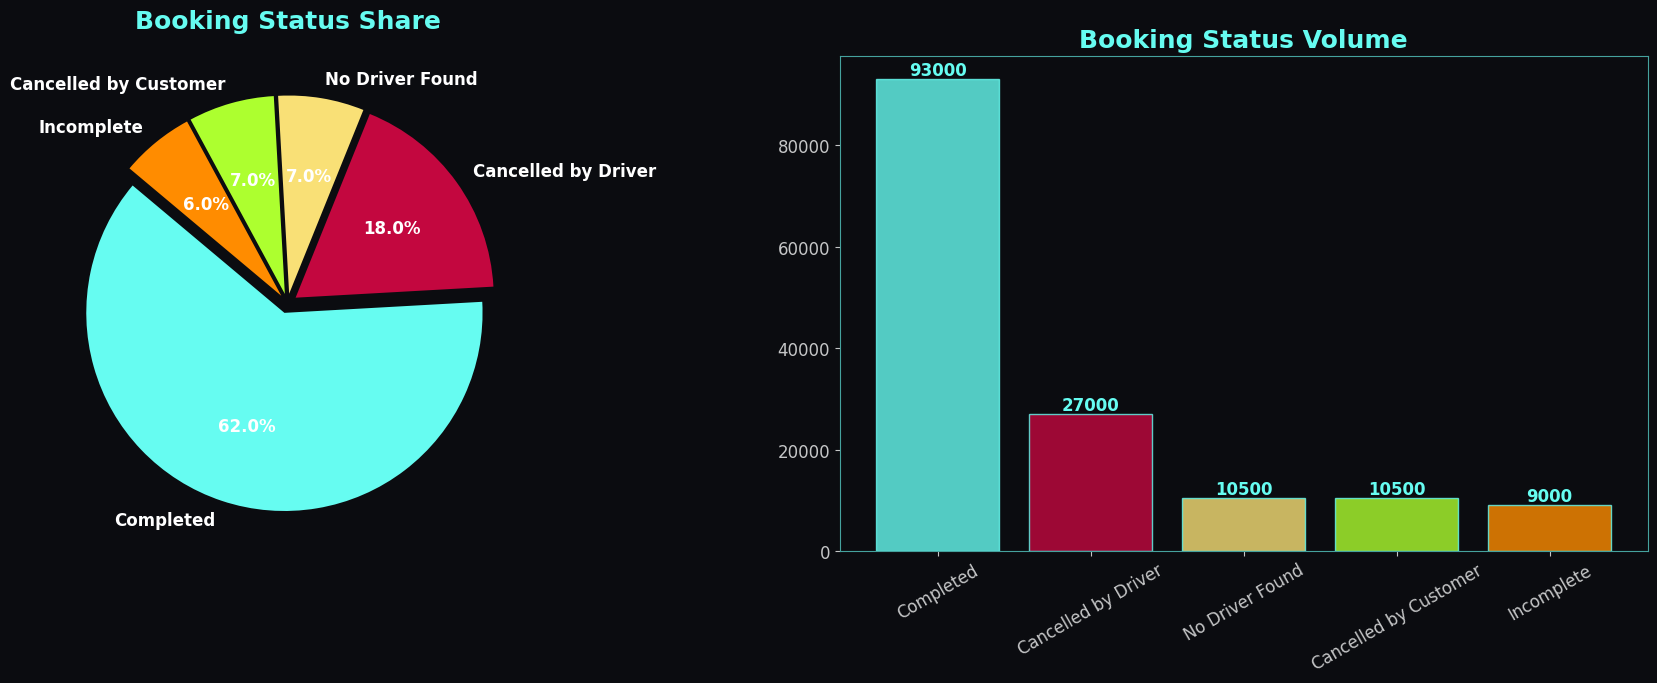

In [9]:
print("\n BOOKING STATUS DISTRIBUTION")
print("-" * 40)
status_counts = df['Booking Status'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%',
            colors=electric_palette, startangle=140, explode=[0.05]*len(status_counts),
            textprops={'color':"w", 'weight':'bold'})
axes[0].set_title('Booking Status Share', pad=20)

bars = axes[1].bar(status_counts.index, status_counts.values, color=electric_palette, edgecolor='#66FCF1', alpha=0.8)
axes[1].set_title('Booking Status Volume')
axes[1].tick_params(axis='x', rotation=30)

for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{int(bar.get_height())}', ha='center', va='bottom', color='#66FCF1', fontweight='bold')

plt.tight_layout()
plt.show()


 VEHICLE TYPE ANALYSIS
----------------------------------------


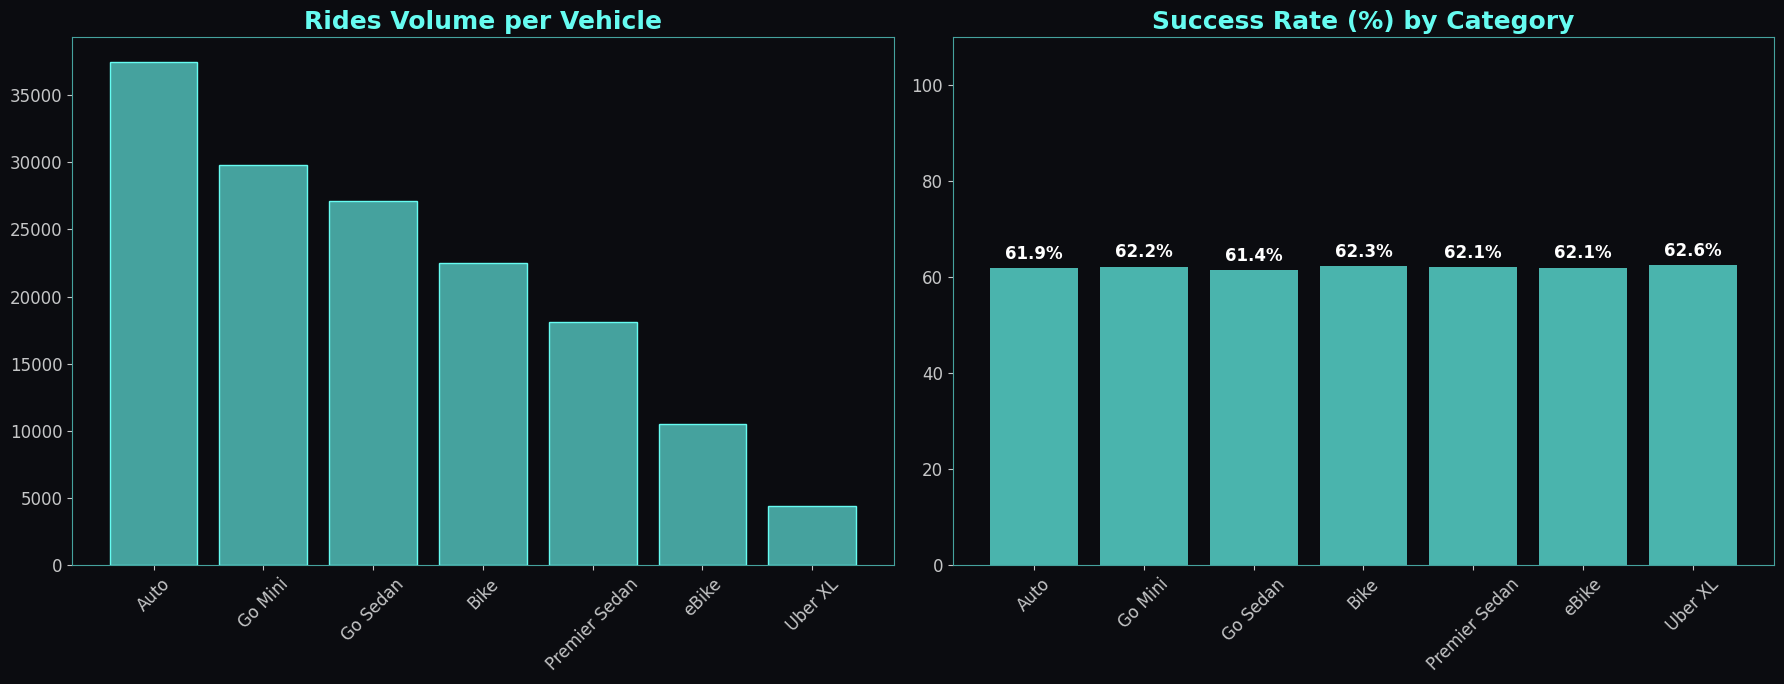

In [10]:
print("\n VEHICLE TYPE ANALYSIS")
print("-" * 40)
vehicle_counts = df['Vehicle Type'].value_counts()
vehicle_success_rate = df[df['Is_Successful']]['Vehicle Type'].value_counts() / df['Vehicle Type'].value_counts() * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].bar(vehicle_counts.index, vehicle_counts.values, color='#45A29E', edgecolor='#66FCF1')
axes[0].set_title('Rides Volume per Vehicle')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(vehicle_success_rate.index, vehicle_success_rate.values, color='#66FCF1', alpha=0.7)
axes[1].set_title('Success Rate (%) by Category')
axes[1].set_ylim(0, 110)
axes[1].tick_params(axis='x', rotation=45)

for i, v in enumerate(vehicle_success_rate.values):
    axes[1].text(i, v + 2, f'{v:.1f}%', ha='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

In [11]:
fig = make_subplots(specs=[[{"secondary_y": True}]])
hourly_rides = df.groupby('Hour').size()
hourly_success_rate = (df[df['Is_Successful']].groupby('Hour').size() / hourly_rides * 100).fillna(0)

fig.add_trace(go.Bar(x=hourly_rides.index, y=hourly_rides.values, name="Rides", marker_color='#1F2833', marker_line_color='#66FCF1', marker_line_width=1.5), secondary_y=False)
fig.add_trace(go.Scatter(x=hourly_success_rate.index, y=hourly_success_rate.values, name="Success Rate %", line=dict(color='#C3073F', width=4)), secondary_y=True)

fig.update_layout(title_text="Hourly Demand & Success Pulse", title_x=0.5, height=600)
pio.renderers.default = "iframe"
fig.show()


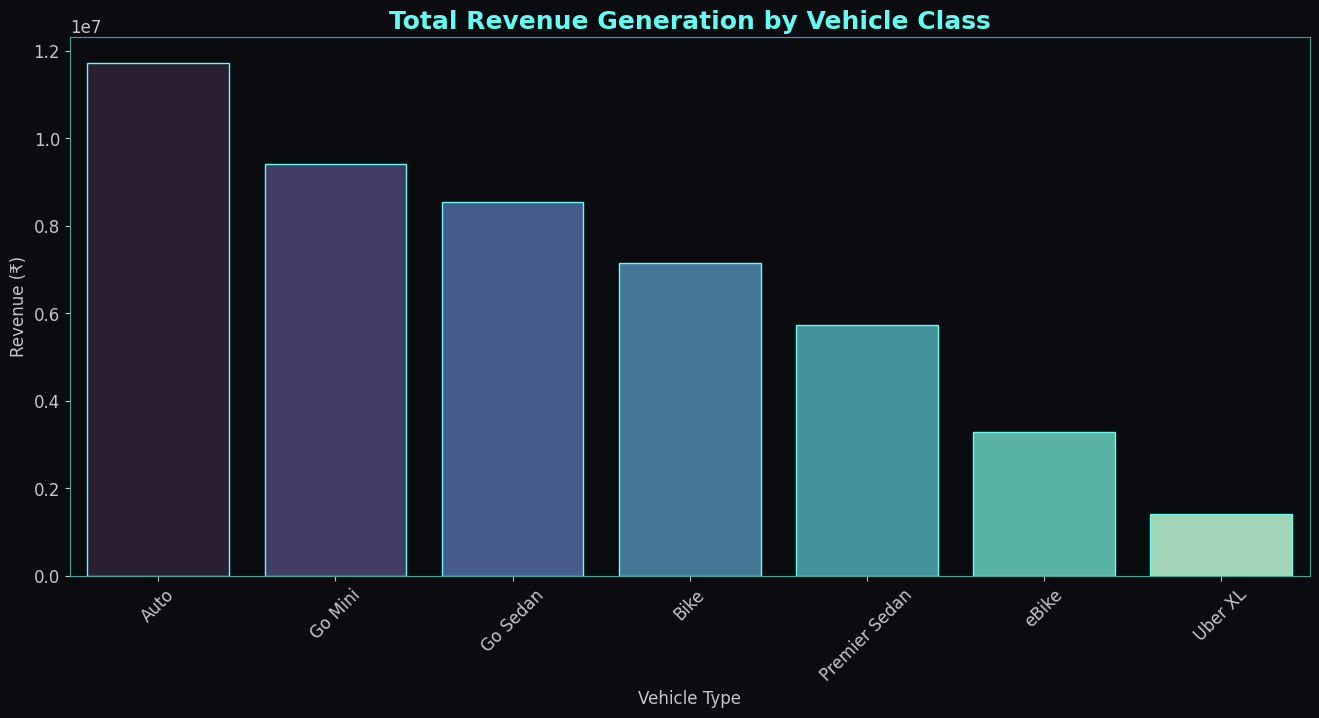

In [12]:
revenue_by_vehicle = df[df['Is_Successful']].groupby('Vehicle Type')['Booking Value'].sum().sort_values(ascending=False)
plt.figure(figsize=(16, 7))
sns.barplot(x=revenue_by_vehicle.index, y=revenue_by_vehicle.values, palette="mako", edgecolor="#66FCF1")
plt.title("Total Revenue Generation by Vehicle Class")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=45)
plt.show()

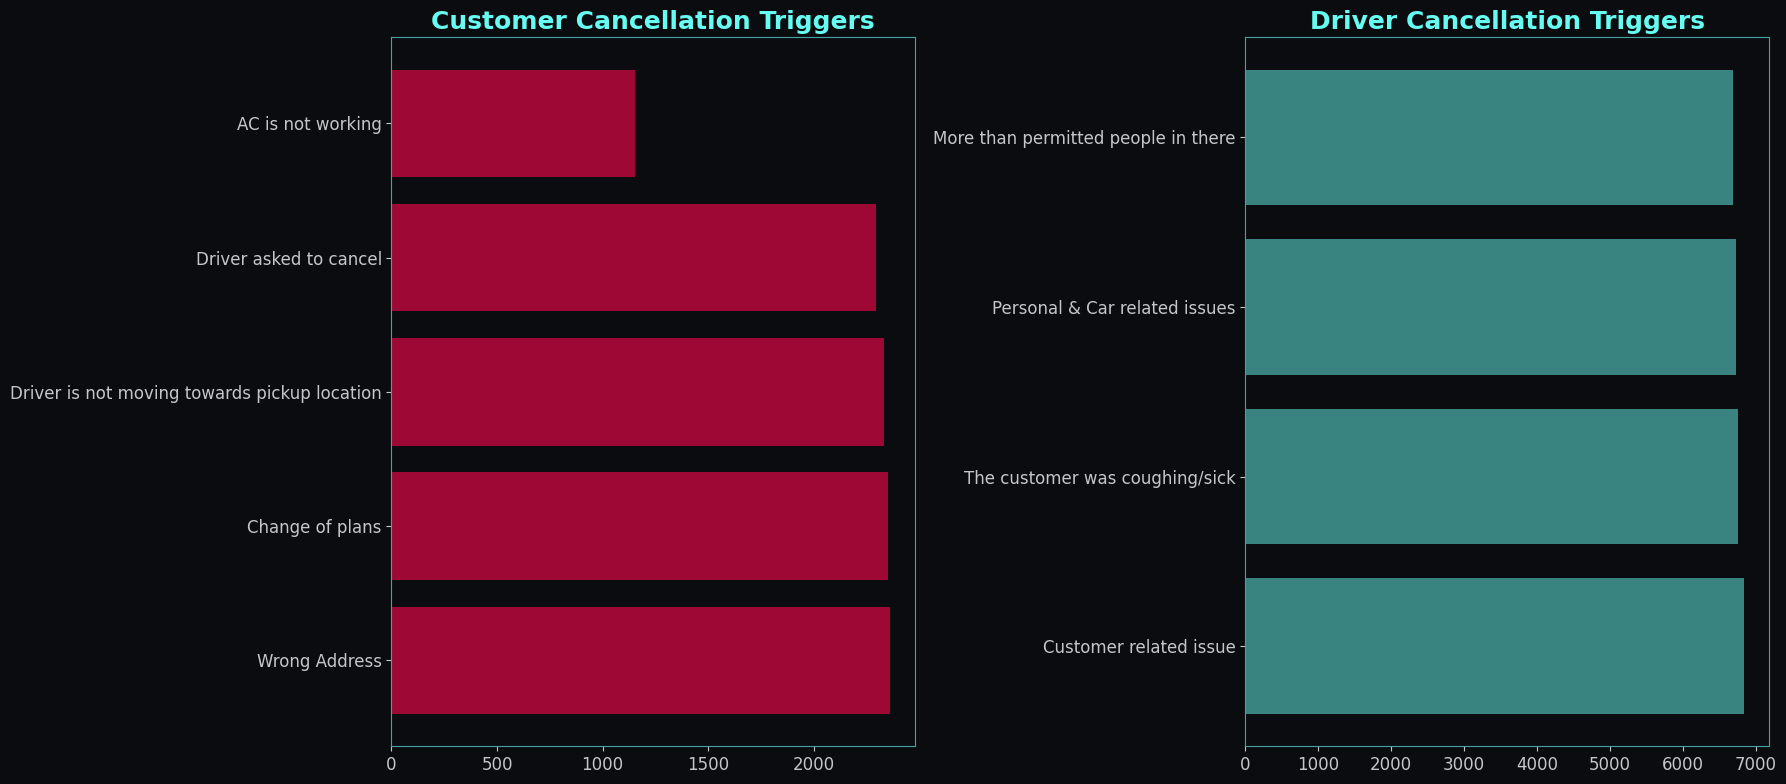

In [13]:
customer_cancellations = df[df['Is_Cancelled_by_Customer']]['Reason for cancelling by Customer'].value_counts()
driver_cancellations = df[df['Is_Cancelled_by_Driver']]['Driver Cancellation Reason'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

axes[0].barh(customer_cancellations.index, customer_cancellations.values, color='#C3073F', alpha=0.8)
axes[0].set_title('Customer Cancellation Triggers')

axes[1].barh(driver_cancellations.index, driver_cancellations.values, color='#45A29E', alpha=0.8)
axes[1].set_title('Driver Cancellation Triggers')

plt.tight_layout()
plt.show()

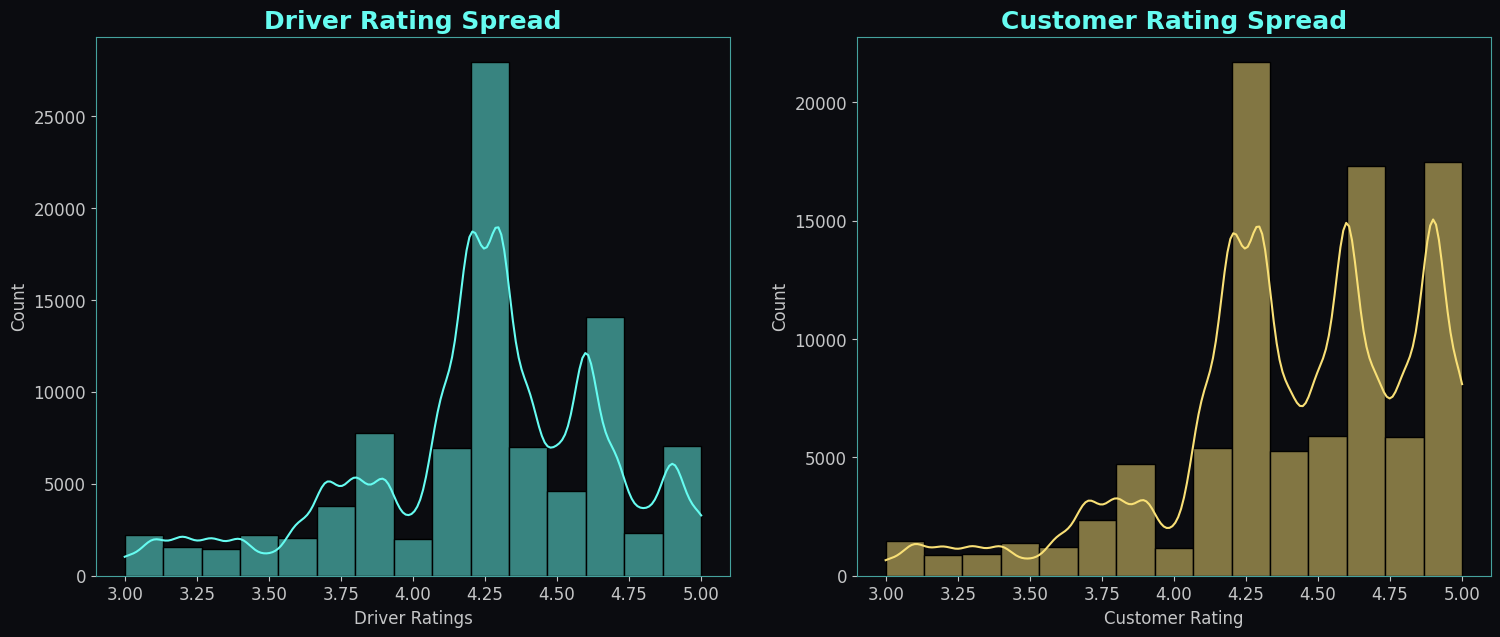

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.histplot(df['Driver Ratings'].dropna(), bins=15, ax=axes[0], color='#66FCF1', kde=True, edgecolor="black")
axes[0].set_title('Driver Rating Spread')

sns.histplot(df['Customer Rating'].dropna(), bins=15, ax=axes[1], color='#F9E076', kde=True, edgecolor="black")
axes[1].set_title('Customer Rating Spread')

plt.show()

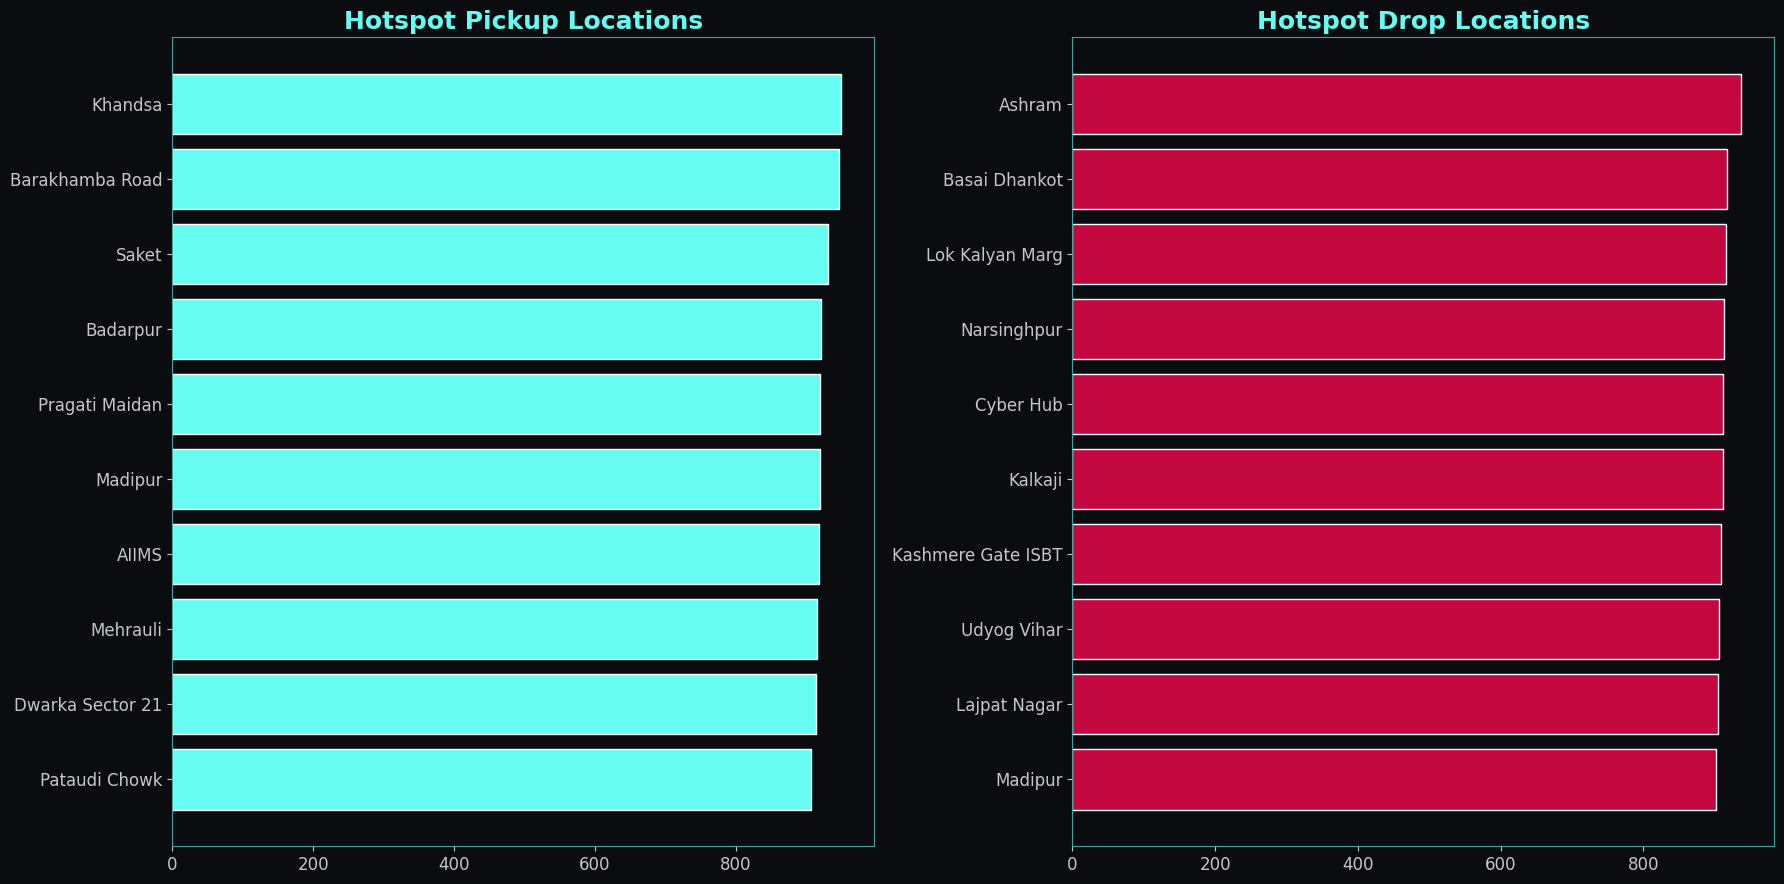

In [15]:
top_pickups = df['Pickup Location'].value_counts().head(10)
top_drops = df['Drop Location'].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

axes[0].barh(top_pickups.index[::-1], top_pickups.values[::-1], color='#66FCF1', edgecolor='white')
axes[0].set_title('Hotspot Pickup Locations')

axes[1].barh(top_drops.index[::-1], top_drops.values[::-1], color='#C3073F', edgecolor='white')
axes[1].set_title('Hotspot Drop Locations')

plt.tight_layout()
plt.show()

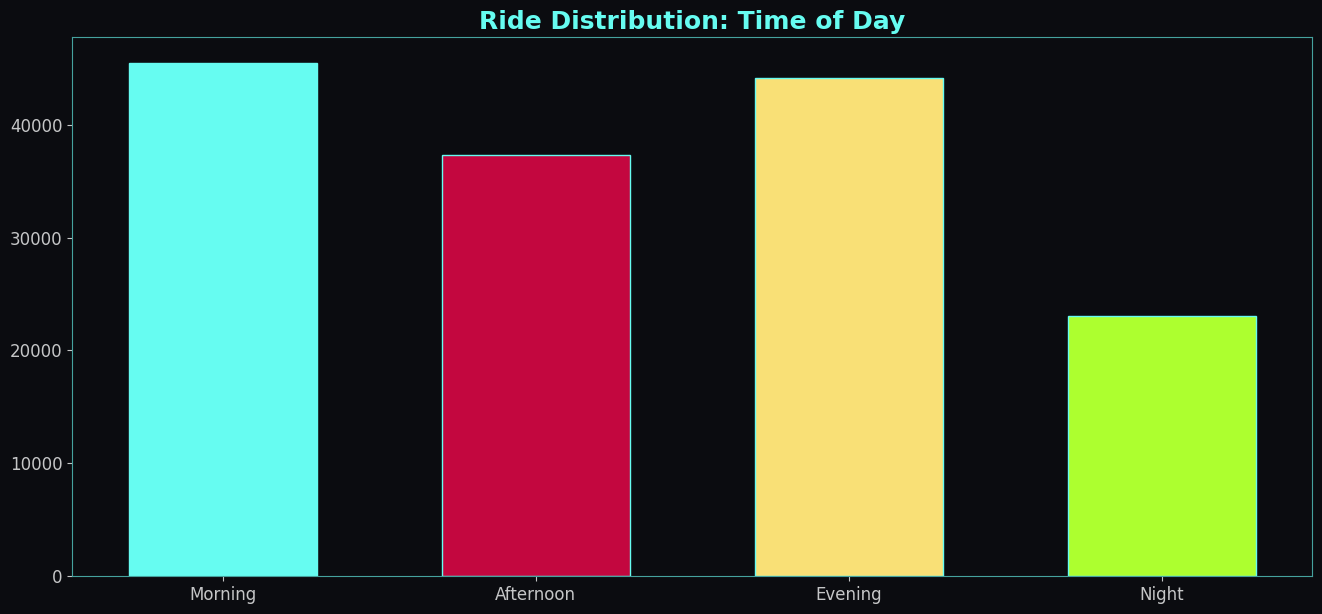

In [16]:
time_of_day_stats = df.groupby('Time_of_Day')['Booking ID'].count().reindex(['Morning', 'Afternoon', 'Evening', 'Night'])
plt.figure(figsize=(16, 7))
plt.bar(time_of_day_stats.index, time_of_day_stats.values, color=electric_palette[:4], edgecolor="#66FCF1", width=0.6)
plt.title("Ride Distribution: Time of Day")
plt.show()

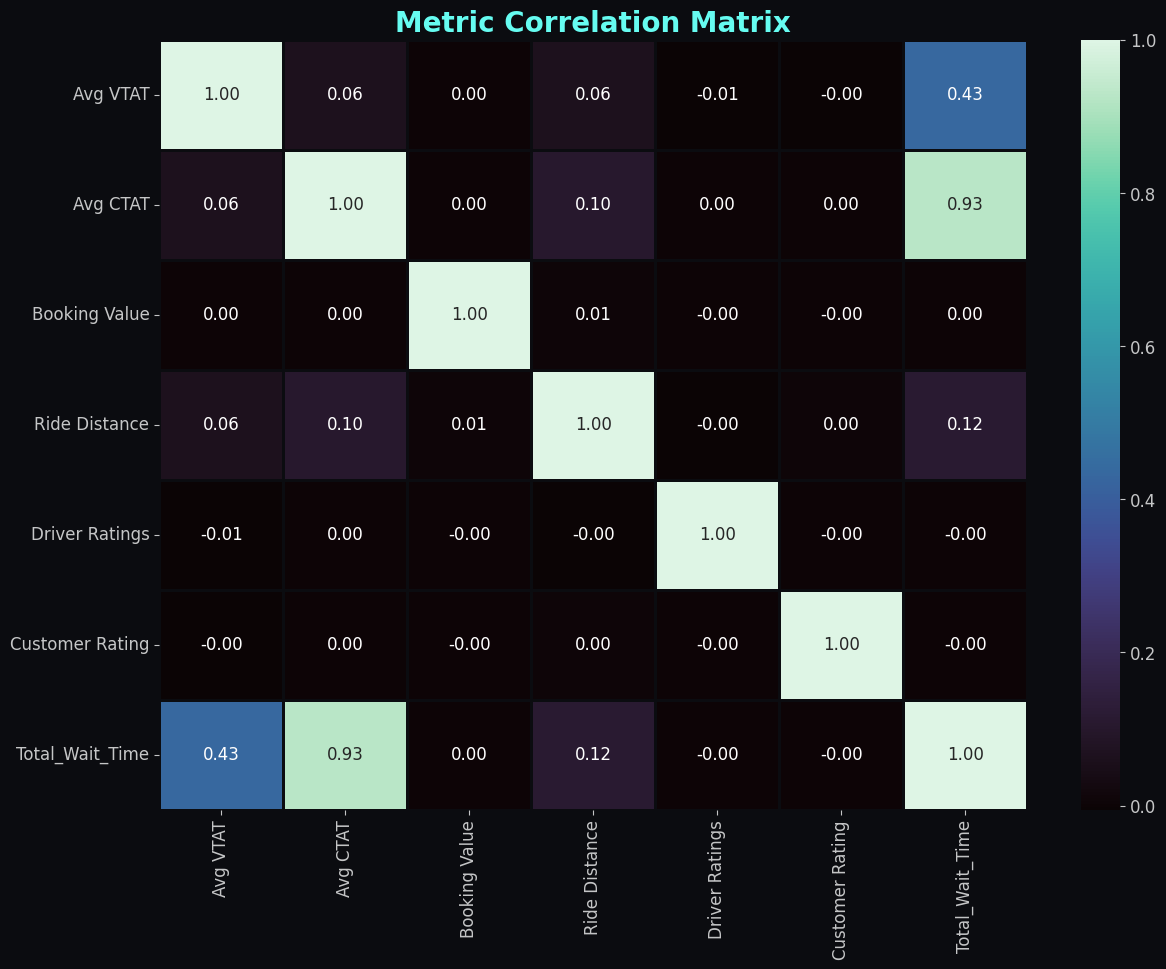

In [17]:
corr_columns = ['Avg VTAT', 'Avg CTAT', 'Booking Value', 'Ride Distance', 'Driver Ratings', 'Customer Rating', 'Total_Wait_Time']
plt.figure(figsize=(14, 10))
sns.heatmap(df[corr_columns].corr(), annot=True, cmap='mako', fmt='.2f', linewidths=2, linecolor='#0B0C10')
plt.title("Metric Correlation Matrix", fontsize=20)
plt.show()

In [18]:
print("\n MONTHLY TRENDS")
print("-" * 40)

monthly_stats = df.groupby('Month').agg({
    'Booking ID': 'count',
    'Is_Successful': 'sum',
    'Booking Value': 'sum'
}).rename(columns={'Booking ID': 'Total_Rides', 'Is_Successful': 'Successful_Rides', 'Booking Value': 'Total_Revenue'})
monthly_stats['Success_Rate'] = (monthly_stats['Successful_Rides'] / monthly_stats['Total_Rides'] * 100).round(2)

fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Bar(x=monthly_stats.index, y=monthly_stats['Total_Rides'],
           name="Total Rides",
           marker_color='#45A29E',
           opacity=0.8,
           marker_line=dict(width=1.5, color='#66FCF1')),
    secondary_y=False,
)

fig.add_trace(
    go.Scatter(x=monthly_stats.index, y=monthly_stats['Total_Revenue'],
               name="Total Revenue (₹)",
               mode='lines+markers',
               marker=dict(size=10, symbol='diamond'),
               line=dict(width=4, color='#C3073F')),
    secondary_y=True,
)

fig.update_xaxes(title_text="Month", tickmode='linear', dtick=1, gridcolor='#1F2833')
fig.update_yaxes(title_text="Number of Rides", secondary_y=False, gridcolor='#1F2833')
fig.update_yaxes(title_text="Revenue (₹)", secondary_y=True, showgrid=False)

fig.update_layout(title_text="Monthly Ride and Revenue Pulse",
                  title_font_size=20, title_x=0.5,
                  hovermode='x unified',
                  height=600,
                  legend=dict(bgcolor='rgba(0,0,0,0)'))

pio.renderers.default = "iframe"
fig.show()


 MONTHLY TRENDS
----------------------------------------



 TOP PERFORMING ROUTES
----------------------------------------


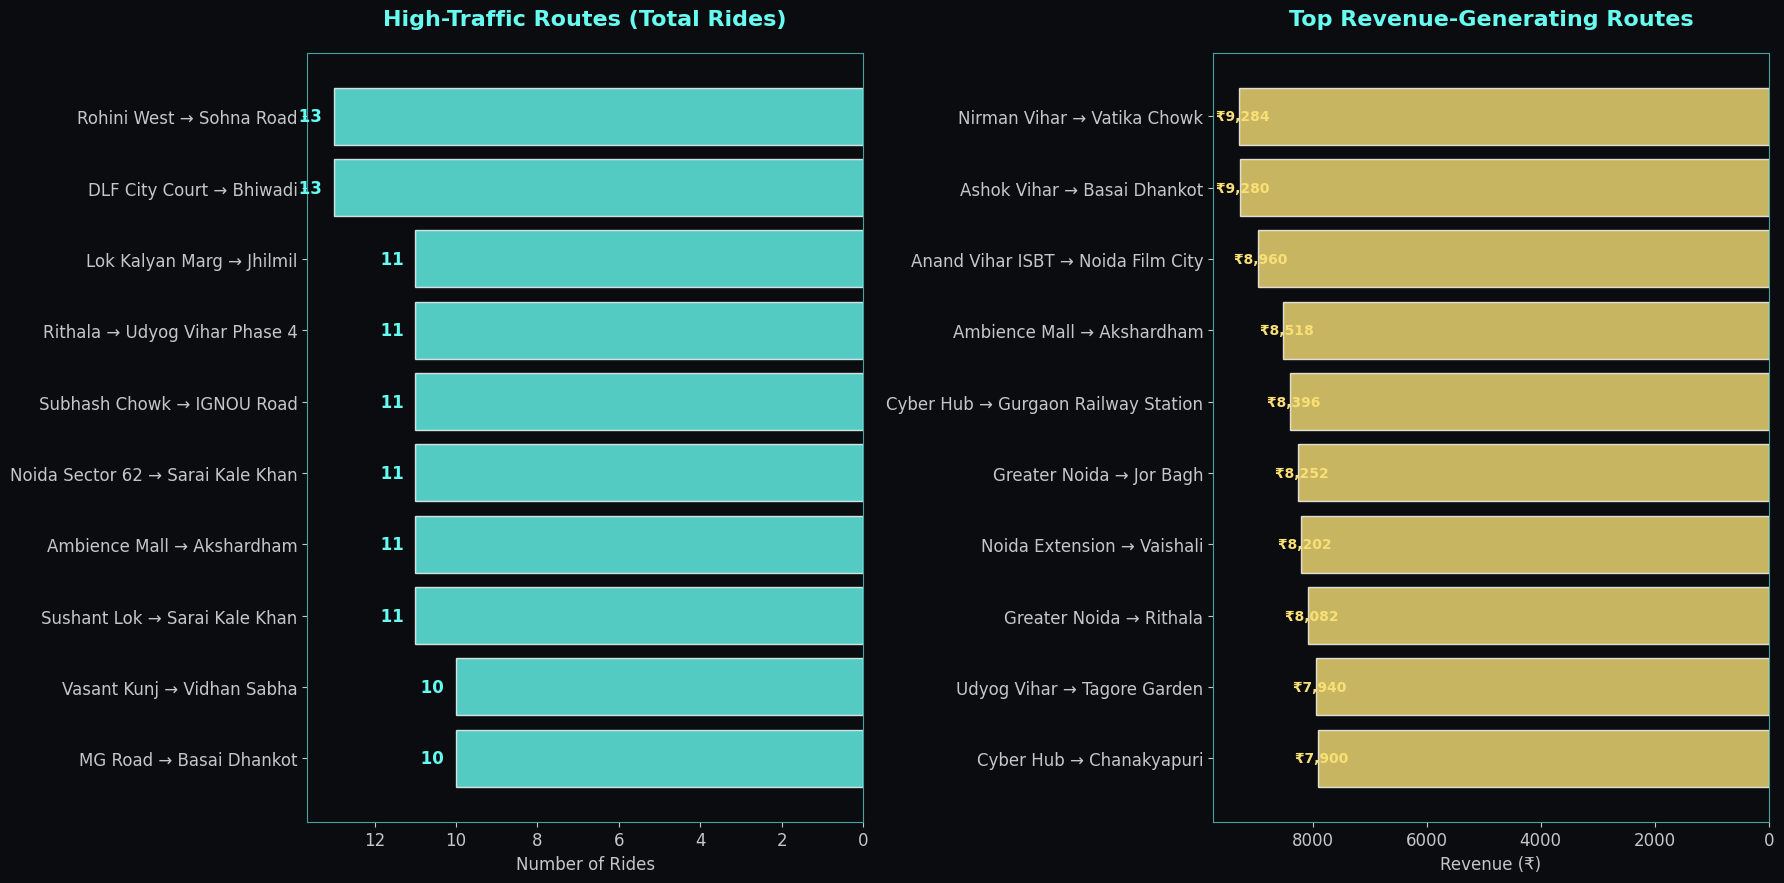

In [19]:
print("\n TOP PERFORMING ROUTES")
print("-" * 40)

df['Route'] = df['Pickup Location'] + ' → ' + df['Drop Location']

top_routes = df[df['Is_Successful']].groupby('Route').size().sort_values(ascending=False).head(10)
top_revenue_routes = df[df['Is_Successful']].groupby('Route')['Booking Value'].sum().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

bars1 = axes[0].barh(top_routes.index[::-1], top_routes.values[::-1], color='#66FCF1', alpha=0.8, edgecolor='white')
axes[0].set_title('High-Traffic Routes (Total Rides)', fontsize=16, pad=20)
axes[0].set_xlabel('Number of Rides')
axes[0].invert_xaxis()

for bar, val in zip(bars1, top_routes.values[::-1]):
    axes[0].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 f' {val}', ha='left', va='center', fontweight='bold', color='#66FCF1')

bars2 = axes[1].barh(top_revenue_routes.index[::-1], top_revenue_routes.values[::-1], color='#F9E076', alpha=0.8, edgecolor='white')
axes[1].set_title('Top Revenue-Generating Routes', fontsize=16, pad=20)
axes[1].set_xlabel('Revenue (₹)')
axes[1].invert_xaxis()

for bar, val in zip(bars2, top_revenue_routes.values[::-1]):
    axes[1].text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
                 f' ₹{val:,.0f}', ha='left', va='center', fontweight='bold', color='#F9E076', fontsize=10)

plt.tight_layout()
plt.show()


 DRIVER PERFORMANCE ANALYSIS
----------------------------------------


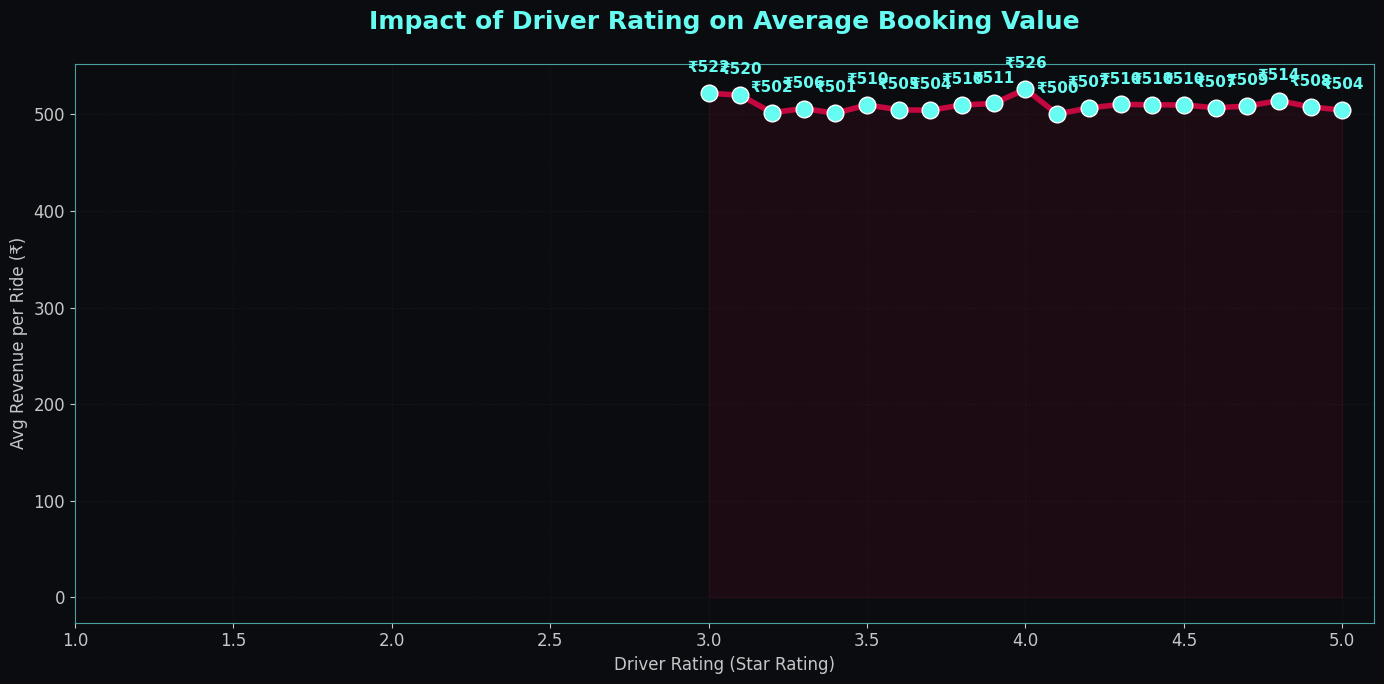

In [20]:
print("\n DRIVER PERFORMANCE ANALYSIS")
print("-" * 40)

rating_revenue = df[df['Is_Successful'] & df['Driver Ratings'].notna()].groupby('Driver Ratings')['Booking Value'].mean()

plt.figure(figsize=(14, 7))

plt.plot(rating_revenue.index, rating_revenue.values,
         marker='o', linestyle='-', linewidth=4, markersize=12,
         color='#C3073F', markerfacecolor='#66FCF1', markeredgecolor='white')

plt.fill_between(rating_revenue.index, rating_revenue.values, color='#C3073F', alpha=0.1)

plt.title('Impact of Driver Rating on Average Booking Value', fontsize=18, pad=25)
plt.xlabel('Driver Rating (Star Rating)', color='#C5C6C7')
plt.ylabel('Avg Revenue per Ride (₹)', color='#C5C6C7')

plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='#1F2833')
plt.xticks(np.arange(1, 5.1, 0.5))

for x, y in rating_revenue.items():
    plt.annotate(f'₹{y:.0f}', (x, y), textcoords="offset points",
                 xytext=(0, 15), ha='center', fontsize=11,
                 fontweight='bold', color='#66FCF1')

plt.tight_layout()
plt.show()

In [21]:
print("\n GENERATING INTERACTIVE DASHBOARD")
print("-" * 40)

fig = make_subplots(
    rows=3, cols=3,
    subplot_titles=('Booking Status Share', 'Revenue by Vehicle Class', 'Hourly Ride Pulse',
                    'Success Rate by Day', 'Preferred Payment Methods', 'Top Cancellation Triggers',
                    'Driver Ratings Spread', 'Hotspot Pickup Locations', 'Monthly Revenue Trend'),
    specs=[[{'type': 'pie'}, {'type': 'bar'}, {'type': 'scatter'}],
           [{'type': 'scatter'}, {'type': 'pie'}, {'type': 'bar'}],
           [{'type': 'histogram'}, {'type': 'bar'}, {'type': 'scatter'}]],
    vertical_spacing=0.12,
    horizontal_spacing=0.1
)

status_counts = df['Booking Status'].value_counts()
fig.add_trace(go.Pie(
    labels=status_counts.index, values=status_counts.values,
    hole=0.4, name="Status", marker=dict(colors=electric_palette)
), row=1, col=1)

rev_veh = df[df['Is_Successful']].groupby('Vehicle Type')['Booking Value'].sum().sort_values(ascending=False)
fig.add_trace(go.Bar(
    x=rev_veh.index, y=rev_veh.values, name="Revenue",
    marker=dict(color=rev_veh.values, colorscale='teal', line=dict(width=1, color='#66FCF1'))
), row=1, col=2)

hourly = df.groupby('Hour').size()
fig.add_trace(go.Scatter(
    x=hourly.index, y=hourly.values, mode='lines+markers',
    name="Rides", line=dict(color='#66FCF1', width=3),
    marker=dict(size=8, color='white')
), row=1, col=3)

daily_success = df.groupby('Day_of_Week')['Is_Successful'].mean() * 100
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_success = daily_success.reindex(days_order)
fig.add_trace(go.Scatter(
    x=daily_success.index, y=daily_success.values, mode='lines+markers',
    name="Success %", line=dict(color='#ADFF2F', width=3)
), row=2, col=1)

payments = df[df['Is_Successful']]['Payment Method'].value_counts()
fig.add_trace(go.Pie(
    labels=payments.index, values=payments.values,
    name="Payment", marker=dict(colors=['#C3073F', '#F9E076', '#45A29E', '#7B68EE'])
), row=2, col=2)

cancel_reasons = df[df['Is_Cancelled_by_Customer']]['Reason for cancelling by Customer'].value_counts().head(5)
fig.add_trace(go.Bar(
    x=cancel_reasons.values, y=cancel_reasons.index, orientation='h',
    name="Cancellation", marker=dict(color='#C3073F', opacity=0.8, line=dict(width=1, color='white'))
), row=2, col=3)

driver_ratings = df[df['Driver Ratings'].notna()]['Driver Ratings']
fig.add_trace(go.Histogram(
    x=driver_ratings, name="Ratings",
    marker=dict(color='#F9E076', opacity=0.7, line=dict(width=1, color='black')),
    nbinsx=15
), row=3, col=1)

top_pickup = df['Pickup Location'].value_counts().head(8)
fig.add_trace(go.Bar(
    x=top_pickup.values, y=top_pickup.index, orientation='h',
    name="Pickups", marker=dict(color='#45A29E', line=dict(width=1, color='#66FCF1'))
), row=3, col=2)

monthly_rev = df[df['Is_Successful']].groupby('Month')['Booking Value'].sum()
fig.add_trace(go.Scatter(
    x=monthly_rev.index, y=monthly_rev.values, mode='lines+markers',
    name="Revenue Trend", line=dict(color='#FF8C00', width=4),
    fill='tozeroy', fillcolor='rgba(255, 140, 0, 0.1)'
), row=3, col=3)

fig.update_layout(
    title_text="OLA RIDE ANALYTICS: INTERACTIVE EXECUTIVE DASHBOARD",
    title_font=dict(size=26, color='#66FCF1', family="Arial, sans-serif"),
    title_x=0.5,
    height=1100,
    width=1500,
    template="electric_midnight+plotly_dark",
    showlegend=False,
    paper_bgcolor='#0B0C10',
    plot_bgcolor='#0B0C10',
    margin=dict(t=120, b=50, l=80, r=80)
)

# Individual Axis Styling for visibility
fig.update_xaxes(showgrid=True, gridcolor='#1F2833', zeroline=False)
fig.update_yaxes(showgrid=True, gridcolor='#1F2833', zeroline=False)
pio.renderers.default = "iframe"
fig.show()


 GENERATING INTERACTIVE DASHBOARD
----------------------------------------


# RECOMMENDATIONS

In [22]:
print("\n RECOMMENDATIONS")
print("="*60)

recommendations = {
    'Operational Improvements': [
        '1. Address "No Driver Found" issue, especially for Go Sedan and Premier Sedan vehicles',
        '2. Reduce driver cancellation rates by improving driver incentives and communication',
        '3. Focus on reducing vehicle breakdowns which cause 40% of incomplete rides'
    ],
    'Customer Experience': [
        '1. Improve driver training to reduce "Driver is not moving towards pickup location" cancellations',
        '2. Address AC-related complaints in Premier Sedan category',
        '3. Enhance customer support for "Wrong Address" issues'
    ],
    'Revenue Optimization': [
        '1. Focus on evening peak hours (5-9 PM) for maximum revenue',
        '2. Optimize pricing for high-demand routes like Gurgaon Sector 56 to various destinations',
        '3. Consider promotions during weekend mornings to boost ridership'
    ],
    'Vehicle Fleet Management': [
        '1. Increase Go Mini and Auto availability during peak hours',
        '2. Consider adding more eBikes for short-distance trips',
        '3. Review Premier Sedan allocation strategy due to lower success rates'
    ],
    'Geographic Expansion': [
        '1. Increase presence in high-demand areas like Gurgaon Sector 56, Cyber Hub',
        '2. Improve coverage in underserved areas',
        '3. Consider strategic partnerships in high-volume pickup locations'
    ]
}

for category, recs in recommendations.items():
    print(f"\n{category}:")
    print("-" * (len(category) + 1))
    for rec in recs:
        print(f"  {rec}")


 RECOMMENDATIONS

Operational Improvements:
-------------------------
  1. Address "No Driver Found" issue, especially for Go Sedan and Premier Sedan vehicles
  2. Reduce driver cancellation rates by improving driver incentives and communication
  3. Focus on reducing vehicle breakdowns which cause 40% of incomplete rides

Customer Experience:
--------------------
  1. Improve driver training to reduce "Driver is not moving towards pickup location" cancellations
  2. Address AC-related complaints in Premier Sedan category
  3. Enhance customer support for "Wrong Address" issues

Revenue Optimization:
---------------------
  1. Focus on evening peak hours (5-9 PM) for maximum revenue
  2. Optimize pricing for high-demand routes like Gurgaon Sector 56 to various destinations
  3. Consider promotions during weekend mornings to boost ridership

Vehicle Fleet Management:
-------------------------
  1. Increase Go Mini and Auto availability during peak hours
  2. Consider adding more eBikes

In [23]:
print("\n EXPORTING CLEANED DATA")
print("-" * 40)

cleaned_df = df.copy()

export_columns = ['Date', 'Year', 'Month', 'Month_Name', 'Day', 'Day_of_Week', 'Hour',
                  'Is_Weekend', 'Time_of_Day', 'Season', 'Booking Status', 'Vehicle Type',
                  'Pickup Location', 'Drop Location', 'Avg VTAT', 'Avg CTAT', 'Total_Wait_Time',
                  'Booking Value', 'Ride Distance', 'Revenue_per_km', 'Driver Ratings',
                  'Customer Rating', 'Payment Method', 'Is_Successful', 'Is_Cancelled_by_Customer',
                  'Is_Cancelled_by_Driver', 'Is_Incomplete', 'Is_No_Driver']

export_columns = [col for col in export_columns if col in cleaned_df.columns]
export_df = cleaned_df[export_columns]

print(f"Cleaned dataset shape: {export_df.shape}")
print(f"Columns in cleaned dataset: {len(export_columns)}")
print("\nPreview of cleaned data:")
export_df.head()


 EXPORTING CLEANED DATA
----------------------------------------
Cleaned dataset shape: (150000, 28)
Columns in cleaned dataset: 28

Preview of cleaned data:


,Date,Year,Month,Month_Name,Day,Day_of_Week,Hour,Is_Weekend,Time_of_Day,Season,...,Ride Distance,Revenue_per_km,Driver Ratings,Customer Rating,Payment Method,Is_Successful,Is_Cancelled_by_Customer,Is_Cancelled_by_Driver,Is_Incomplete,Is_No_Driver
0,2024-03-23,2024,3,March,23,Saturday,12,True,Afternoon,Spring,...,NaN,NaN,NaN,NaN,NaN,False,False,False,False,True
1,2024-11-29,2024,11,November,29,Friday,18,False,Evening,Fall,...,5.73,41.361257,NaN,NaN,UPI,False,False,False,True,False
2,2024-08-23,2024,8,August,23,Friday,8,False,Morning,Summer,...,13.58,46.170839,4.9,4.9,Debit Card,True,False,False,False,False
3,2024-10-21,2024,10,October,21,Monday,17,False,Evening,Fall,...,34.02,12.228101,4.6,5.0,UPI,True,False,False,False,False
4,2024-09-16,2024,9,September,16,Monday,22,False,Night,Fall,...,48.21,15.287285,4.1,4.3,UPI,True,False,False,False,False


# COMPLETE RIDE-SHARING DATA ANALYSIS - SUMMARY

In [24]:
print("\n" + "="*80)
print("COMPLETE RIDE-SHARING DATA ANALYSIS - SUMMARY")
print("="*80)

print(f"""
Dataset Overview:
- Total Records: {len(df):,}
- Total Successful Rides: {df['Is_Successful'].sum():,} ({df['Is_Successful'].sum()/len(df)*100:.1f}%)
- Total Revenue: ₹{df[df['Is_Successful']]['Booking Value'].sum():,.0f}
- Total Distance Covered: {df[df['Is_Successful']]['Ride Distance'].sum():,.2f} km
- Unique Customers: {df['Customer ID'].nunique():,}
- Unique Vehicle Types: {df['Vehicle Type'].nunique()}

Key Findings:
1. Success Rate: {df['Is_Successful'].sum()/len(df)*100:.1f}% of rides are successfully completed
2. Most Popular Vehicle: {df['Vehicle Type'].mode()[0]}
3. Peak Hour: {df['Hour'].mode()[0]} ({df[df['Hour']==df['Hour'].mode()[0]]['Time_of_Day'].iloc[0]})
4. Most Common Payment Method: {df[df['Is_Successful']]['Payment Method'].mode()[0]}
5. Average Driver Rating: {df['Driver Ratings'].mean():.2f}/5.0
6. Average Customer Rating: {df['Customer Rating'].mean():.2f}/5.0

Main Issues Identified:
1. No Driver Found: {df['Is_No_Driver'].sum():,} rides ({df['Is_No_Driver'].sum()/len(df)*100:.1f}%)
2. Customer Cancellations: {df['Is_Cancelled_by_Customer'].sum():,} rides
3. Driver Cancellations: {df['Is_Cancelled_by_Driver'].sum():,} rides
4. Incomplete Rides: {df['Is_Incomplete'].sum():,} rides

Top Performing Routes:
1. {top_routes.index[0] if len(top_routes) > 0 else 'N/A'}: {top_routes.iloc[0] if len(top_routes) > 0 else 0} rides
2. {top_routes.index[1] if len(top_routes) > 1 else 'N/A'}: {top_routes.iloc[1] if len(top_routes) > 1 else 0} rides
3. {top_routes.index[2] if len(top_routes) > 2 else 'N/A'}: {top_routes.iloc[2] if len(top_routes) > 2 else 0} rides
""")


COMPLETE RIDE-SHARING DATA ANALYSIS - SUMMARY

Dataset Overview:
- Total Records: 150,000
- Total Successful Rides: 93,000 (62.0%)
- Total Revenue: ₹47,260,574
- Total Distance Covered: 2,418,045.84 km
- Unique Customers: 148,788
- Unique Vehicle Types: 7

Key Findings:
1. Success Rate: 62.0% of rides are successfully completed
2. Most Popular Vehicle: Auto
3. Peak Hour: 18 (Evening)
4. Most Common Payment Method: UPI
5. Average Driver Rating: 4.23/5.0
6. Average Customer Rating: 4.40/5.0

Main Issues Identified:
1. No Driver Found: 10,500 rides (7.0%)
2. Customer Cancellations: 10,500 rides
3. Driver Cancellations: 27,000 rides
4. Incomplete Rides: 9,000 rides

Top Performing Routes:
1. Rohini West → Sohna Road: 13 rides
2. DLF City Court → Bhiwadi: 13 rides
3. Lok Kalyan Marg → Jhilmil: 11 rides



In [25]:
print("\nAnalysis Complete! 🎉")


Analysis Complete! 🎉
